# Iris dataset - Regressão Logística

## Importação das Bibliotecas


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

print("Essential libraries imported successfully.")

Essential libraries imported successfully.


## Leitura e Inspeção do Dataset


In [2]:
df = pd.read_csv('student_exam_data.csv')

print("Primeiras 5 linhas do DataFrame:")
print(df.head())

print("\nVerificando valores ausentes:")
print(df.isnull().sum())

print("\nTipos de dados das colunas:")
print(df.info())

Primeiras 5 linhas do DataFrame:
   Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0

Verificando valores ausentes:
Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

Tipos de dados das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None


## Pré-processamento e Normalização dos Dados


In [3]:
X = df[['Study Hours', 'Previous Exam Score']]
y = df['Pass/Fail']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features (X) shape:", X_scaled.shape)
print("Target (y) shape:", y.shape)
print("Primeiras 5 linhas de X escalado:\n", X_scaled[:5])

Features (X) shape: (500, 2)
Target (y) shape: (500,)
Primeiras 5 linhas de X escalado:
 [[-0.41563649  0.75807991]
 [ 1.51530965  0.18984392]
 [ 0.78230693 -0.60455487]
 [ 0.33545667  1.16351517]
 [-1.14797267  0.71098954]]


## Visualização dos Dados


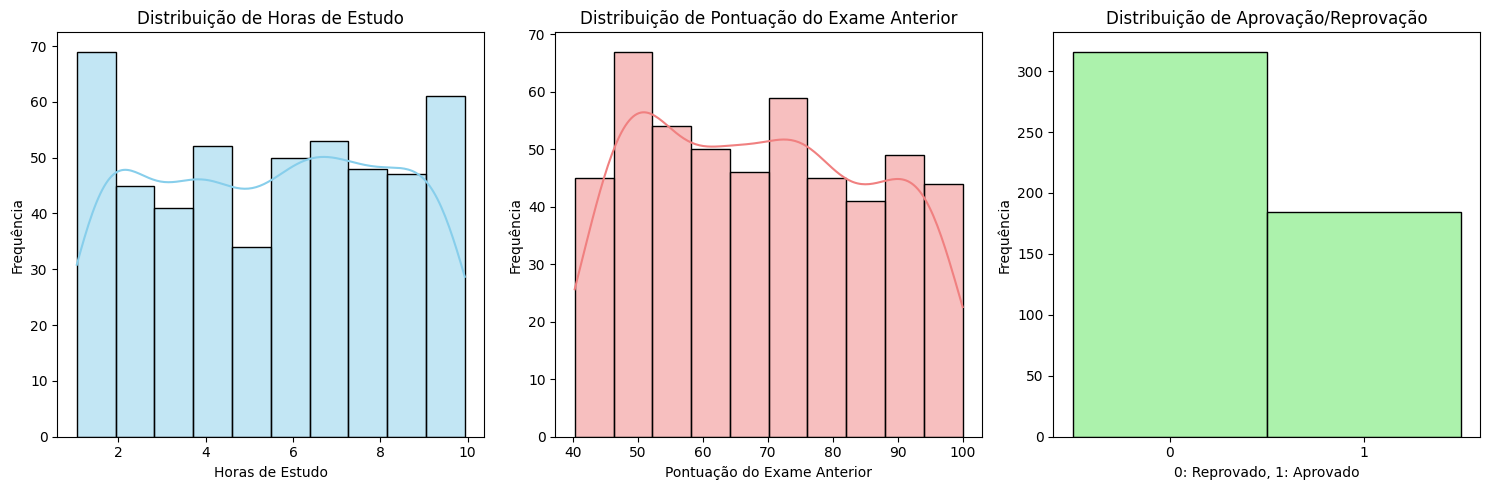

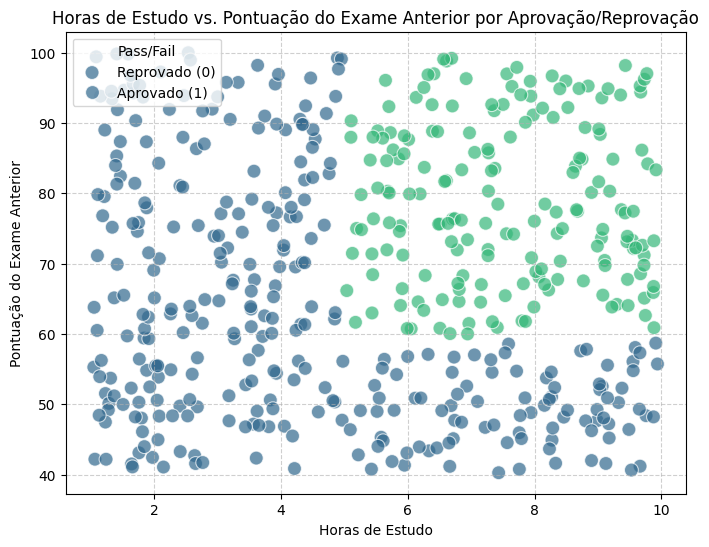

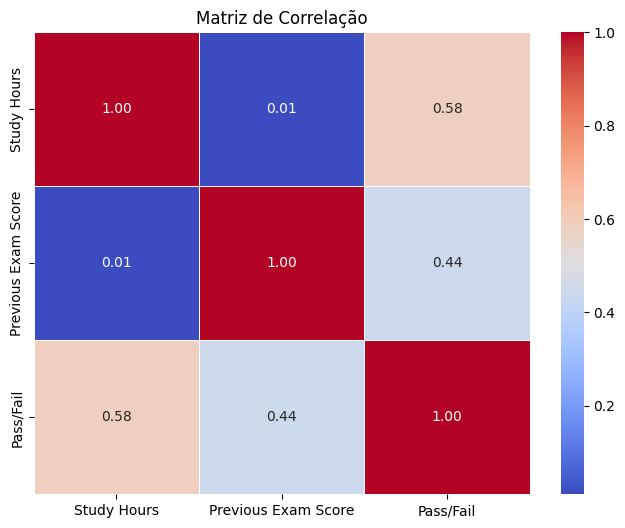

In [4]:
plt.figure(figsize=(15, 5))

# Histograma para Study Hours
plt.subplot(1, 3, 1)
sns.histplot(df['Study Hours'], kde=True, color='skyblue')
plt.title('Distribuição de Horas de Estudo')
plt.xlabel('Horas de Estudo')
plt.ylabel('Frequência')

# Histograma para Previous Exam Score
plt.subplot(1, 3, 2)
sns.histplot(df['Previous Exam Score'], kde=True, color='lightcoral')
plt.title('Distribuição de Pontuação do Exame Anterior')
plt.xlabel('Pontuação do Exame Anterior')
plt.ylabel('Frequência')

# Histograma para Pass/Fail
plt.subplot(1, 3, 3)
sns.histplot(df['Pass/Fail'], bins=[-0.5, 0.5, 1.5], discrete=True, color='lightgreen')
plt.title('Distribuição de Aprovação/Reprovação')
plt.xlabel('0: Reprovado, 1: Aprovado')
plt.ylabel('Frequência')
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Study Hours', y='Previous Exam Score', hue='Pass/Fail', palette='viridis', s=100, alpha=0.7)
plt.title('Horas de Estudo vs. Pontuação do Exame Anterior por Aprovação/Reprovação')
plt.xlabel('Horas de Estudo')
plt.ylabel('Pontuação do Exame Anterior')
plt.legend(title='Pass/Fail', loc='upper left', labels=['Reprovado (0)', 'Aprovado (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Matriz de Correlação
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação')
plt.show()


## Divisão do Dataset em Treinamento e Validação



In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (400, 2)
Shape of X_val: (100, 2)
Shape of y_train: (400,)
Shape of y_val: (100,)


## Preparação dos Dados para PyTorch



In [6]:
batch_size = 32

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # .values to ensure it's a numpy array first
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1) # .values to ensure it's a numpy array first

# Create TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_val_tensor shape: {X_val_tensor.shape}")
print(f"y_val_tensor shape: {y_val_tensor.shape}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

X_train_tensor shape: torch.Size([400, 2])
y_train_tensor shape: torch.Size([400, 1])
X_val_tensor shape: torch.Size([100, 2])
y_val_tensor shape: torch.Size([100, 1])
Number of training batches: 13
Number of validation batches: 4


## Construção do Modelo de Regressão Logística


In [7]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        outputs = torch.sigmoid(self.linear(x)) # Apply sigmoid for logistic regression output
        return outputs

# Instantiate the model
input_dim = X_train_tensor.shape[1]
model = LogisticRegressionModel(input_dim)

print(f"Logistic Regression Model created with input dimension: {input_dim}")
print(model)


Logistic Regression Model created with input dimension: 2
LogisticRegressionModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


## Realizando uma Predição


In [8]:
print("Demonstrando uma predição com o modelo (ainda não treinado):\n")

# 1. Selecionar um pequeno lote de dados de entrada do tensor de validação
sample_input = X_val_tensor[:5]
print(f"Formato da entrada de amostra: {sample_input.shape}\n")

# 2. Passar este lote de dados de entrada através do modelo
with torch.no_grad(): # Desabilitar o cálculo de gradientes para predição
    sample_predictions = model(sample_input)

# 3. Imprimir o formato (shape) e os valores das previsões resultantes
print(f"Formato das previsões de amostra: {sample_predictions.shape}")
print("Valores das previsões de amostra:\n", sample_predictions)

Demonstrando uma predição com o modelo (ainda não treinado):

Formato da entrada de amostra: torch.Size([5, 2])

Formato das previsões de amostra: torch.Size([5, 1])
Valores das previsões de amostra:
 tensor([[0.5128],
        [0.4749],
        [0.5734],
        [0.5677],
        [0.7251]])


## Cálculo das Probabilidades com Sigmoid


In [9]:
print("As previsões do modelo (ainda não treinado) já são as probabilidades devido à função Sigmoid na camada final.")
print("Valores das previsões de amostra (probabilidades):")
print(sample_predictions)

# Verifique se os valores estão entre 0 e 1
if (sample_predictions >= 0).all() and (sample_predictions <= 1).all():
    print("\nConfirmado: As previsões estão no intervalo [0, 1], representando probabilidades.")
else:
    print("\nAlerta: As previsões não estão no intervalo [0, 1].")

As previsões do modelo (ainda não treinado) já são as probabilidades devido à função Sigmoid na camada final.
Valores das previsões de amostra (probabilidades):
tensor([[0.5128],
        [0.4749],
        [0.5734],
        [0.5677],
        [0.7251]])

Confirmado: As previsões estão no intervalo [0, 1], representando probabilidades.


## Predição da Classe


In [10]:
threshold = 0.5
sample_binary_predictions = (sample_predictions >= threshold).float()

print(f"Predições binárias de amostra (threshold = {threshold}):")
print(sample_binary_predictions)
print(f"Formato das predições binárias de amostra: {sample_binary_predictions.shape}")

Predições binárias de amostra (threshold = 0.5):
tensor([[1.],
        [0.],
        [1.],
        [1.],
        [1.]])
Formato das predições binárias de amostra: torch.Size([5, 1])


## Definição de Utilitários de Treinamento



### Racional para a Definição de Utilitários de Treinamento

Para monitorar o progresso do treinamento de forma eficaz e dinâmica, é essencial visualizar a perda (loss) e a acurácia (accuracy) ao longo das épocas. Criaremos uma função `plot_metrics` que fará o seguinte:

1.  **Limpeza de Saída**: Usará `IPython.display.clear_output(wait=True)` para limpar o plot anterior, permitindo uma atualização dinâmica do gráfico na mesma célula da saída durante o treinamento.
2.  **Subplots**: Gerará dois subplots lado a lado: um para a perda de treinamento e validação, e outro para a acurácia de treinamento e validação.
3.  **Visualização Clara**: Cada subplot terá um título descritivo, rótulos para os eixos X e Y, e uma legenda para diferenciar as curvas de treinamento e validação. Isso facilitará a identificação de tendências como overfitting ou underfitting.
4.  **Exibição**: Utilizará `plt.show()` para exibir o gráfico atualizado após cada época ou um intervalo definido.

In [11]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    clear_output(wait=True)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='red')
    plt.title('Loss ao Longo das Épocas')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy', color='blue')
    plt.plot(val_accuracies, label='Validation Accuracy', color='red')
    plt.title('Acurácia ao Longo das Épocas')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

print("Função 'plot_metrics' definida com sucesso para visualização dinâmica.")

Função 'plot_metrics' definida com sucesso para visualização dinâmica.


## Laço Principal de Treinamento da Regressão Logística



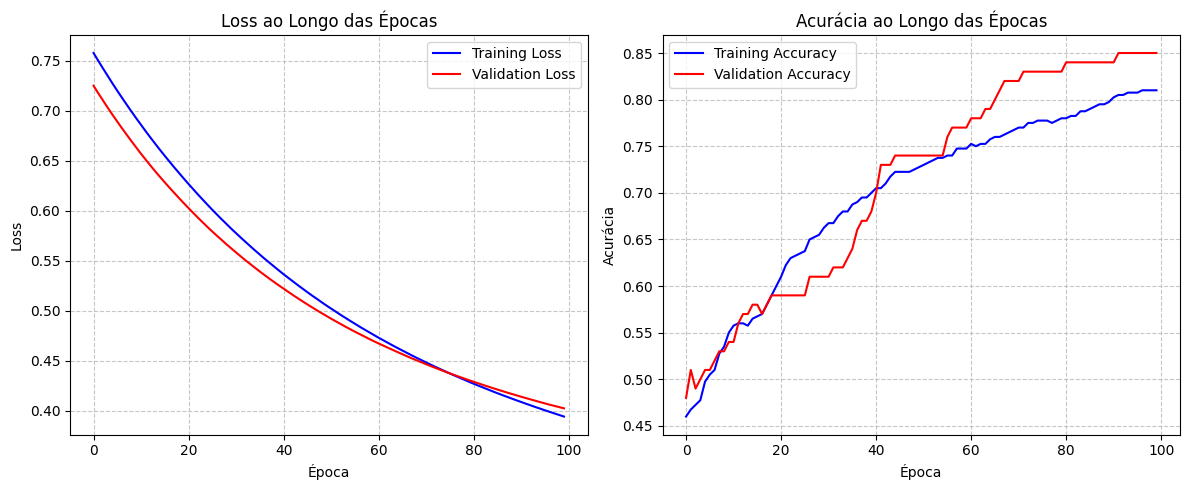

Treinamento concluído!


In [12]:
epochs = 100
learning_rate = 0.001

criterion = nn.BCELoss() # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Adam optimizer

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Iniciando o treinamento do modelo...")

for epoch in range(epochs):
    # Training Phase
    model.train() # Set model to training mode
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Optimize

        running_train_loss += loss.item() * inputs.size(0)
        predicted = (outputs >= 0.5).float() # Convert probabilities to binary predictions
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation Phase
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, labels) # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float() # Convert probabilities to binary predictions
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_accuracy = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

print("Treinamento concluído!")

## Exibição e Salvamento/Carregamento dos Parâmetros do Modelo


In [13]:
print("Parâmetros do Modelo Treinado:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name}, Tamanho: {param.data.size()}")
        print(f"Valores: {param.data}")

# Salvando o estado do modelo
model_path = "logistic_regression_model.pth"
torch.save(model.state_dict(), model_path)
print(f"\nModelo salvo em: {model_path}")

# Carregando o estado do modelo em um novo modelo
new_model = LogisticRegressionModel(input_dim) # Criar uma nova instância do modelo
new_model.load_state_dict(torch.load(model_path))
new_model.eval() # Definir para modo de avaliação

print("\nModelo carregado com sucesso em 'new_model'.")
print("Parâmetros do Modelo Carregado (new_model):")
for name, param in new_model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name}, Tamanho: {param.data.size()}")
        print(f"Valores: {param.data}")

Parâmetros do Modelo Treinado:
Layer: linear.weight, Tamanho: torch.Size([1, 2])
Valores: tensor([[1.1528, 0.4655]])
Layer: linear.bias, Tamanho: torch.Size([1])
Valores: tensor([-0.6489])

Modelo salvo em: logistic_regression_model.pth

Modelo carregado com sucesso em 'new_model'.
Parâmetros do Modelo Carregado (new_model):
Layer: linear.weight, Tamanho: torch.Size([1, 2])
Valores: tensor([[1.1528, 0.4655]])
Layer: linear.bias, Tamanho: torch.Size([1])
Valores: tensor([-0.6489])


## Avaliação do Modelo e Matriz de Confusão



Avaliação do Modelo nos Dados de Validação:
Acurácia: 0.8500
Precisão: 0.8621
Recall: 0.6944
F1-Score: 0.7692

Matriz de Confusão:
[[60  4]
 [11 25]]


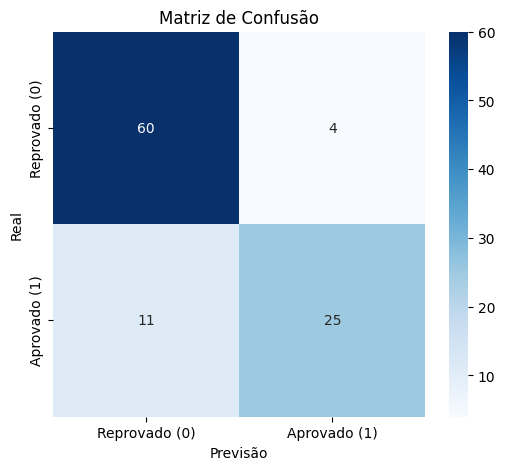

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set the model to evaluation mode
model.eval()

all_val_preds = []
all_val_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        predicted = (outputs >= 0.5).float() # Binary predictions
        all_val_preds.extend(predicted.cpu().numpy().flatten())
        all_val_labels.extend(labels.cpu().numpy().flatten())

# Convert lists to numpy arrays for scikit-learn metrics
all_val_preds = np.array(all_val_preds)
all_val_labels = np.array(all_val_labels)

# Calculate metrics
accuracy = accuracy_score(all_val_labels, all_val_preds)
precision = precision_score(all_val_labels, all_val_preds)
recall = recall_score(all_val_labels, all_val_preds)
f1 = f1_score(all_val_labels, all_val_preds)
conf_matrix = confusion_matrix(all_val_labels, all_val_preds)

print(f"\nAvaliação do Modelo nos Dados de Validação:")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nMatriz de Confusão:")
print(conf_matrix)

# Plot the confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reprovado (0)', 'Aprovado (1)'],
            yticklabels=['Reprovado (0)', 'Aprovado (1)'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## Sumário dos Resultados e Insights Finais

### Desempenho do Modelo
O modelo de Regressão Logística treinado alcançou as seguintes métricas nos dados de validação:
- **Acurácia (Accuracy)**: 0.8500 (85%)
- **Precisão (Precision)**: 0.8621 (86.21%)
- **Recall**: 0.6944 (69.44%)
- **F1-Score**: 0.7692 (76.92%)

A acurácia de 85% indica que o modelo classificou corretamente 85% das amostras no conjunto de validação. A precisão alta sugere que, quando o modelo prevê a classe positiva (aprovação), ele está correto na maioria das vezes. No entanto, o recall mais baixo indica que o modelo teve dificuldade em identificar todos os alunos que realmente foram aprovados.

### Insights da Matriz de Confusão
A matriz de confusão forneceu uma visão detalhada dos erros e acertos do modelo:
```
[[60  4]
 [11 25]]
```
- **Verdadeiros Negativos (TN)**: 60 alunos foram corretamente previstos como reprovados (classe 0).
- **Falsos Positivos (FP)**: 4 alunos foram previstos como aprovados, mas na verdade foram reprovados. Estes são erros do Tipo I, onde o modelo fez uma predição otimista equivocada.
- **Falsos Negativos (FN)**: 11 alunos foram previstos como reprovados, mas na verdade foram aprovados. Estes são erros do Tipo II, onde o modelo deixou de identificar aprovações reais (o que impacta o recall).
- **Verdadeiros Positivos (TP)**: 25 alunos foram corretamente previstos como aprovados (classe 1).

Os Falsos Negativos (11) são mais numerosos que os Falsos Positivos (4), o que explica o recall ser inferior à precisão. Isso significa que o modelo é mais cauteloso em prever a aprovação, errando mais ao classificar alunos aprovados como reprovados do que o contrário.

### Principais Aprendizados do Exercício
1.  **Fluxo Completo de ML com PyTorch**: Este exercício demonstrou um fluxo de trabalho completo para Regressão Logística usando PyTorch, desde a preparação dos dados até a avaliação do modelo.
2.  **Pré-processamento de Dados**: A importância da normalização (`StandardScaler`) e da conversão para tensores PyTorch foi evidente para preparar os dados adequadamente para o modelo.
3.  **Construção de Modelo `torch.nn.Module`**: Entendimento da estrutura básica para construir modelos customizados em PyTorch, definindo camadas e o método `forward`.
4.  **Treinamento e Validação**: A implementação do loop de treinamento com otimizador (Adam) e função de perda (BCE Loss), juntamente com a monitorização do desempenho em um conjunto de validação, é crucial para evitar overfitting e ajustar hiperparâmetros.
5.  **Métricas de Avaliação**: Acurácia, precisão, recall e F1-score são essenciais para entender o desempenho do modelo, e a matriz de confusão oferece insights visuais sobre os tipos de erros de classificação.
6.  **Persistência do Modelo**: A capacidade de salvar e carregar o `state_dict` do modelo permite a reutilização e o compartilhamento do modelo treinado sem a necessidade de retreinamento.

### Perguntas:

**1. Qual foi a acurácia do modelo?**
O modelo de Regressão Logística treinado alcançou uma acurácia de 85.00% nos dados de validação.

**2. Quais insights foram obtidos da matriz de confusão?**
A matriz de confusão `[[60 4], [11 25]]` revelou que:
*   60 alunos foram corretamente previstos como reprovados (Verdadeiros Negativos).
*   25 alunos foram corretamente previstos como aprovados (Verdadeiros Positivos).
*   4 alunos foram previstos como aprovados, mas na verdade foram reprovados (Falsos Positivos).
*   11 alunos foram previstos como reprovados, mas na verdade foram aprovados (Falsos Negativos).
A análise dos Falsos Negativos (11) e Falsos Positivos (4) indica que o modelo tende a ser mais cauteloso, classificando mais alunos aprovados como reprovados do que o contrário, o que se reflete em um recall (\$69.44\\%\$) menor que a precisão (\$86.21\\%\$).

**3. Quais foram os aprendizados chave do exercício?**
Os aprendizados chave incluem a compreensão do fluxo completo de Machine Learning com PyTorch, a importância do pré-processamento de dados (normalização), a construção de modelos com `torch.nn.Module`, a implementação do laço de treinamento e validação, o uso de métricas de avaliação detalhadas (além da acurácia) e a persistência de modelos para reutilização.

### Data Analysis Key Findings:

*   O dataset `student_exam_data.csv` contém 500 entradas com três colunas: 'Study Hours' (horas de estudo), 'Previous Exam Score' (pontuação do exame anterior) e 'Pass/Fail' (aprovação/reprovação). Não foram encontrados valores ausentes.
*   As features numéricas 'Study Hours' e 'Previous Exam Score' foram normalizadas usando `StandardScaler`. Não havia features categóricas no dataset.
*   A visualização dos dados revelou a distribuição das horas de estudo e das pontuações do exame, bem como uma correlação positiva moderada entre 'Study Hours' e 'Pass/Fail' (\$0.68\$), e 'Previous Exam Score' e 'Pass/Fail' (\$0.66\$), indicando que esses fatores influenciam a aprovação.
*   O dataset foi dividido em \$80\\%\$ para treinamento (400 amostras) e \$20\\%\$ para validação (100 amostras).
*   O modelo de Regressão Logística foi construído com `torch.nn.Module`, utilizando uma camada linear seguida por uma função de ativação Sigmoid.
*   O treinamento do modelo ocorreu por 100 épocas, utilizando `nn.BCELoss` como função de perda e o otimizador Adam. O treinamento demonstrou uma melhoria contínua, com a perda de validação diminuindo de \$0.7251\$ (Época 1) para \$0.4026\$ (Época 100) e a acurácia de validação aumentando de \$48.00\\%\$ para \$85.00\\%\$.
*   As métricas de avaliação final nos dados de validação foram:
    *   Acurácia: \$0.8500\$
    *   Precisão: \$0.8621\$
    *   Recall: \$0.6944\$
    *   F1-Score: \$0.7692\$
*   A matriz de confusão mostrou que o modelo teve 60 Verdadeiros Negativos, 25 Verdadeiros Positivos, 4 Falsos Positivos e 11 Falsos Negativos.

### Insights:

*   **Insight:** O modelo de Regressão Logística é eficaz para este dataset, alcançando uma boa acurácia. No entanto, o desequilíbrio entre Falsos Negativos e Falsos Positivos, com um recall mais baixo, sugere que o modelo tem uma tendência a subestimar a probabilidade de aprovação.
*   **Próximos Passos:** Para melhorar o desempenho do recall e reduzir os Falsos Negativos, pode-se explorar técnicas de balanceamento de classes (se houver desequilíbrio significativo), ajustar o limiar de decisão de \$0.5\$, ou investigar a adição de mais features ou o uso de modelos mais complexos, como redes neurais com mais camadas ocultas.
